## Topic 1: Introduction to Adam Optimizer

### 1. Introduction

**What is Adam?**  
Adam stands for **Adaptive Moment Estimation**. It is currently the most famous and most widely used optimization technique in deep learning.

**Why is it important?**  
When you work with neural networks (like CNNs or other AI models), you almost always need an optimizer to train them. Adam is often the go‑to choice because it consistently gives good results across many different types of problems.

**Real‑life use:**  
- Training image classifiers (CNNs)
- Natural language processing models
- Almost any deep learning project – many practitioners start with Adam as their first optimizer

---

### 2. Detailed Explanation

#### The Core Idea Behind Adam

Adam **combines two powerful concepts** from earlier optimization techniques:

| Concept | Where it comes from | What it does |
|---------|---------------------|---------------|
| **Momentum** | Momentum optimizer | Helps descend faster and smooth out the path to the minimum |
| **Learning rate adaptation** | RMSprop / AdaGrad | Adjusts the learning rate automatically so you don’t have to tune it much |

> **Analogy:**  
> Imagine driving to the bottom of a valley.  
> - **Momentum** is like your car's inertia – it keeps you moving smoothly and prevents sudden stops.  
> - **Learning rate adaptation** is like automatically adjusting your brake pressure based on the steepness of the road.  
> Adam uses **both** at the same time.

#### Why Combine Them?

Earlier optimizers each had problems:

| Optimizer | Problem |
|-----------|---------|
| **Batch Gradient Descent** | Too slow |
| **Momentum** | Oscillates (zigzags) past the minimum before settling |
| **Nesterov Accelerated Gradient (NAG)** | Better at damping oscillations, but still slow on sparse data |
| **AdaGrad** | Learning rate decays so much that updates stop completely |
| **RMSprop** | Fixes AdaGrad’s decay problem, but doesn’t use momentum |

**Adam’s solution:** Take the best parts of **momentum** (for speed and smoothness) and **RMSprop** (for adaptive learning rates). The result is a powerful, well‑rounded optimizer.

#### The Name "Adaptive Moment Estimation"

- **Moment** refers to statistical moments:
  - **First moment** = mean (related to momentum – the `m` term)
  - **Second moment** = uncentered variance (related to RMSprop – the `v` term)
- **Adaptive** = the optimizer adjusts the learning rate for each parameter based on these moments

---

### 3. Key Points

- Adam = **Adaptive Moment Estimation**
- It combines **momentum** (for faster, smoother descent) with **adaptive learning rates** (from RMSprop)
- Most widely used optimizer in deep learning today
- Works well on **non‑convex** problems (real neural networks)
- Reduces the need to manually tune the learning rate
- Default hyperparameters often work well out of the box

---

### 4. Common Mistakes

| Mistake | Why it’s wrong | How to avoid |
|---------|----------------|--------------|
| Using Adam without understanding its components | You won’t know when it fails or how to fix it | Learn momentum and RMSprop first |
| Thinking Adam is always the best | Sometimes other optimizers (momentum, RMSprop) work better on specific problems | Try multiple optimizers and compare |
| Changing default parameters without reason | Default β₁=0.9, β₂=0.999 work well for most cases | Only tune hyperparameters after testing defaults |

---

### 5. Interview / Exam Questions

**Q1:** What does Adam stand for?  
**A:** Adaptive Moment Estimation.

**Q2:** Which two earlier optimization concepts does Adam combine?  
**A:** Momentum (first moment) and adaptive learning rates from RMSprop (second moment).

**Q3:** Why is Adam called "adaptive"?  
**A:** Because it adjusts the learning rate automatically for each parameter based on past gradients.

**Q4:** What is a good starting optimizer for a new deep learning project?  
**A:** Adam is often a good starting point. If results are poor, try RMSprop or momentum.

---

### 6. Revision Notes (Quick Recap)

- Adam = **Adaptive Moment Estimation**
- Most **famous and widely used** deep learning optimizer
- **Combines:** Momentum + RMSprop
- **Two main ideas:**
  - First moment (mean) → momentum behavior
  - Second moment (variance) → adaptive learning rate
- Works well on **non‑convex** problems (real neural networks)
- Reduces manual learning rate tuning
- Default β₁ = 0.9, β₂ = 0.999 (configurable)
- **Good starting point** for most deep learning tasks

---


## Topic 2: Mathematical Formulation of Adam

### 1. Introduction

Adam's mathematical formulation combines the update rules from **momentum** and **RMSprop** into a single set of equations. Don't let the math intimidate you – each piece has a clear purpose, and most deep learning libraries implement it for you. Understanding the math helps you debug and tune the optimizer when needed.

**Why understand the math?**  
Even if you never implement Adam from scratch, knowing what happens inside helps you:
- Choose better hyperparameters
- Diagnose training problems (e.g., why updates stop or oscillate)
- Answer interview questions confidently

---

### 2. Detailed Explanation
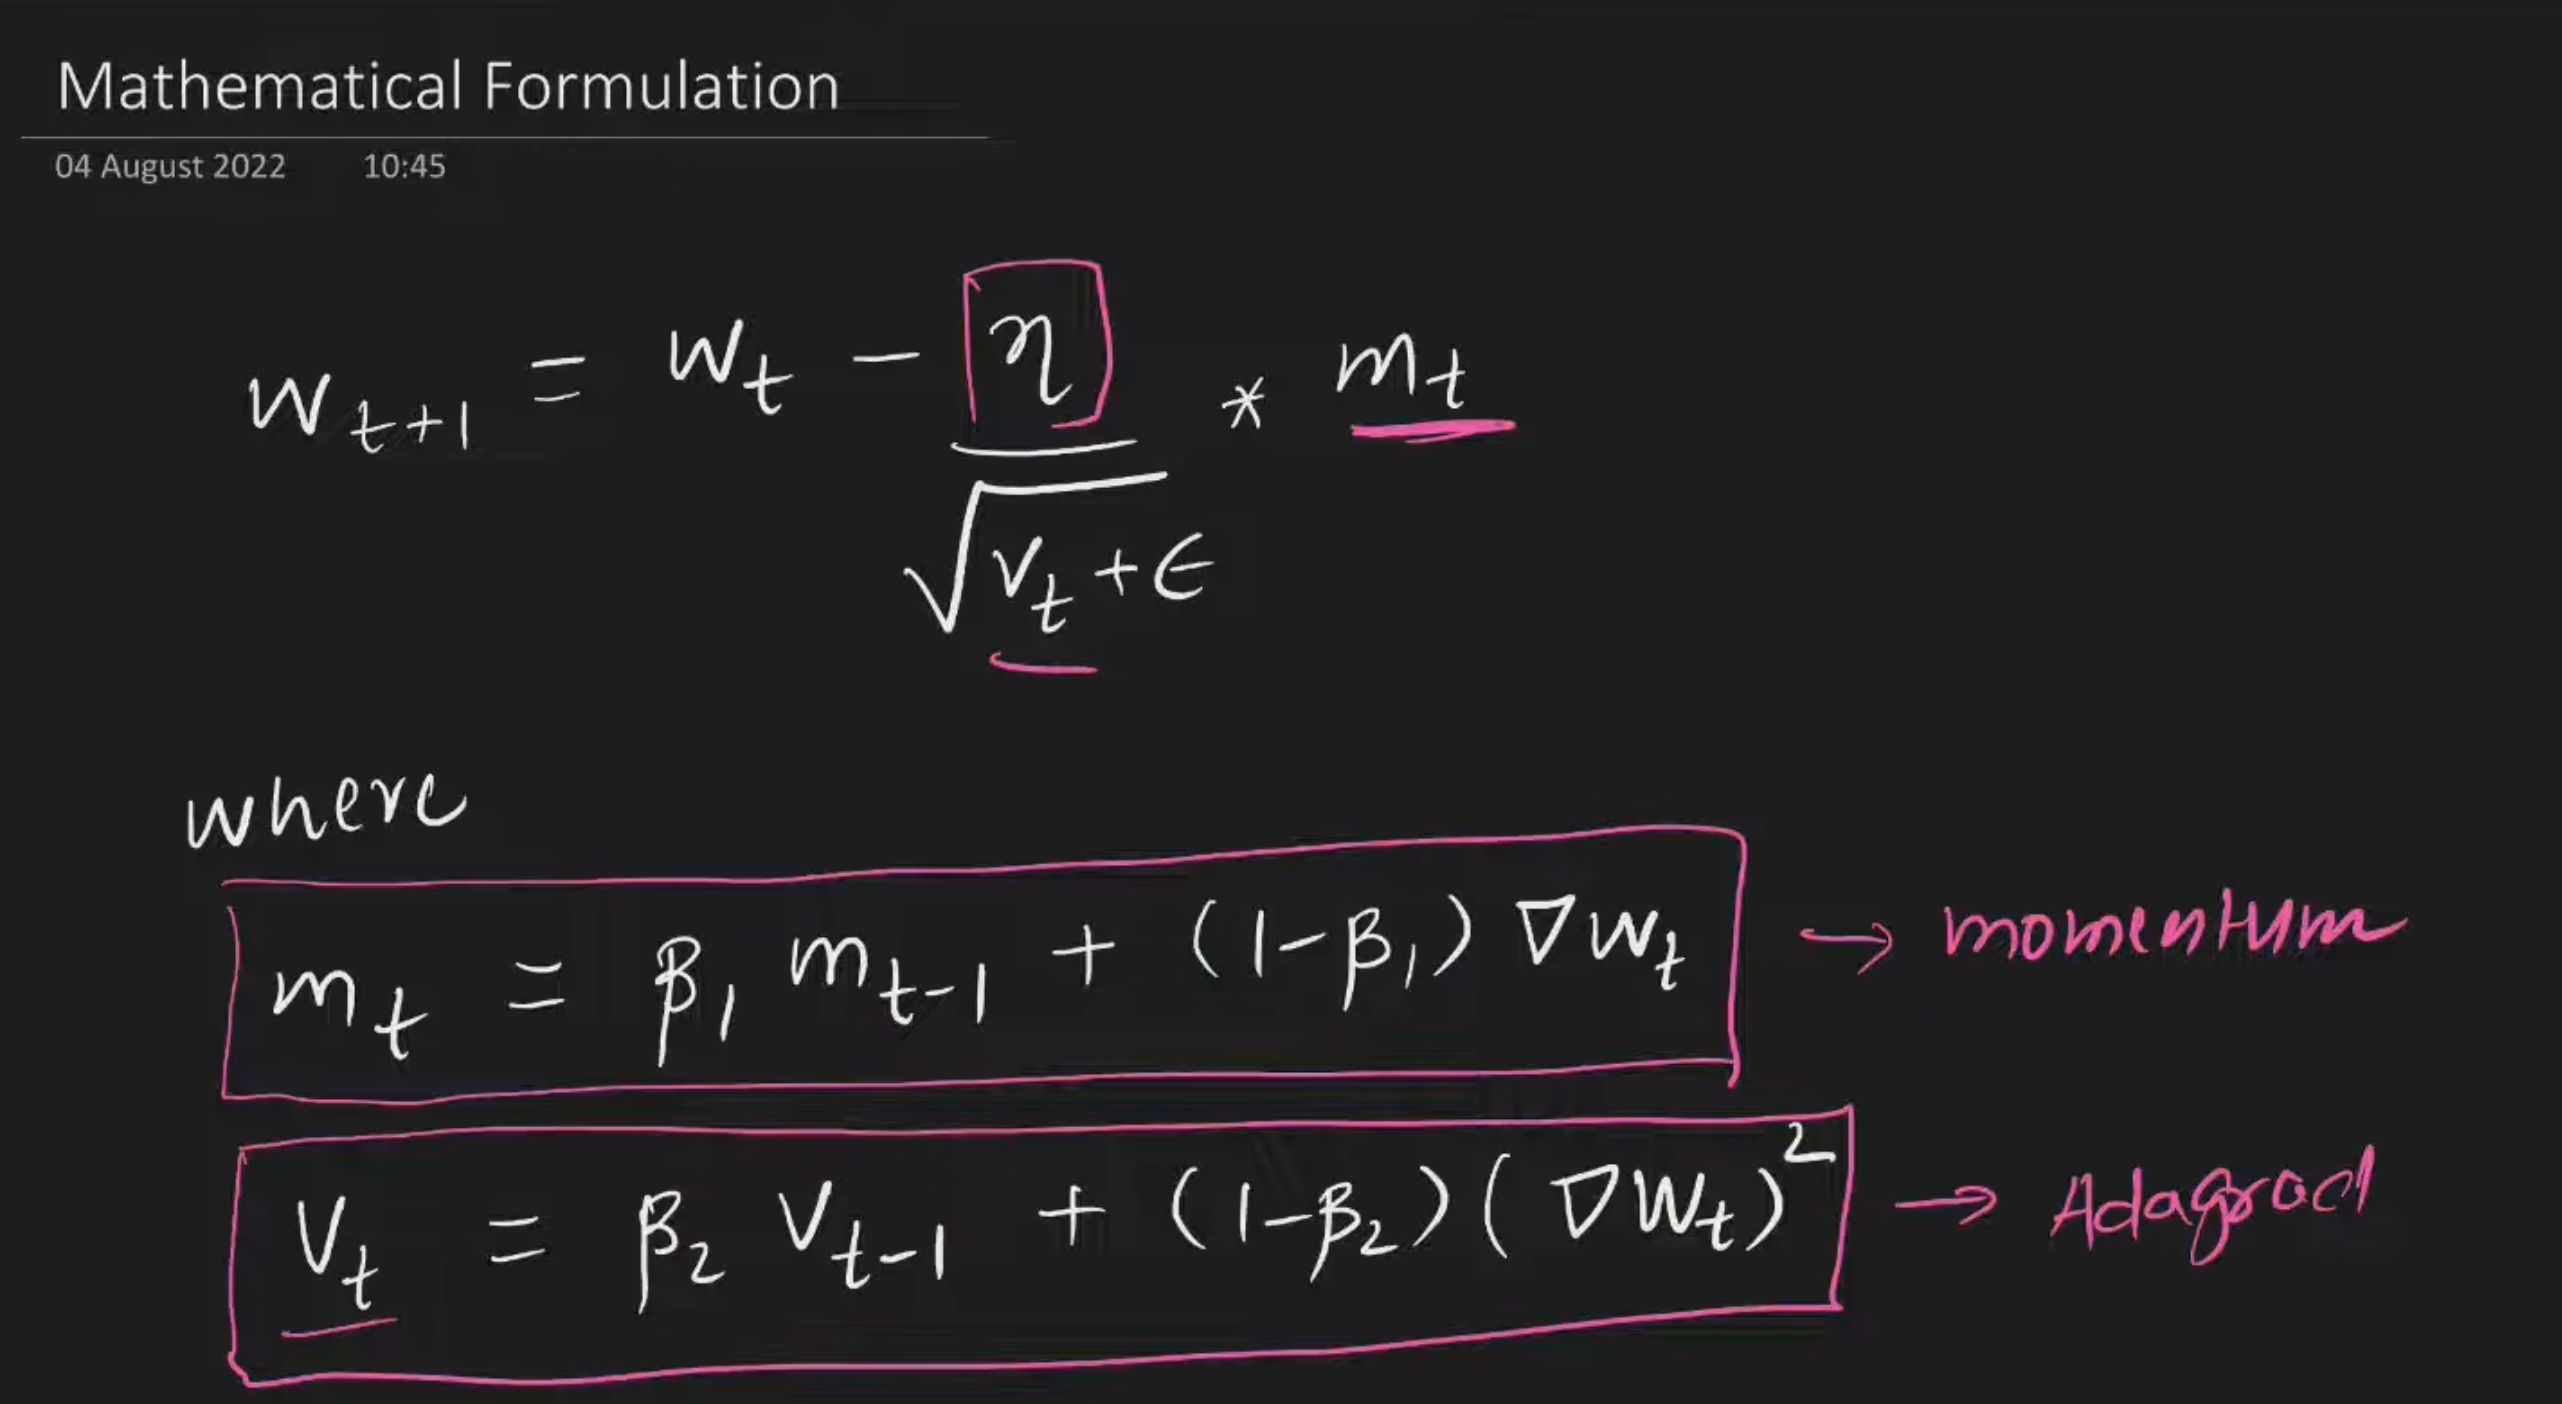
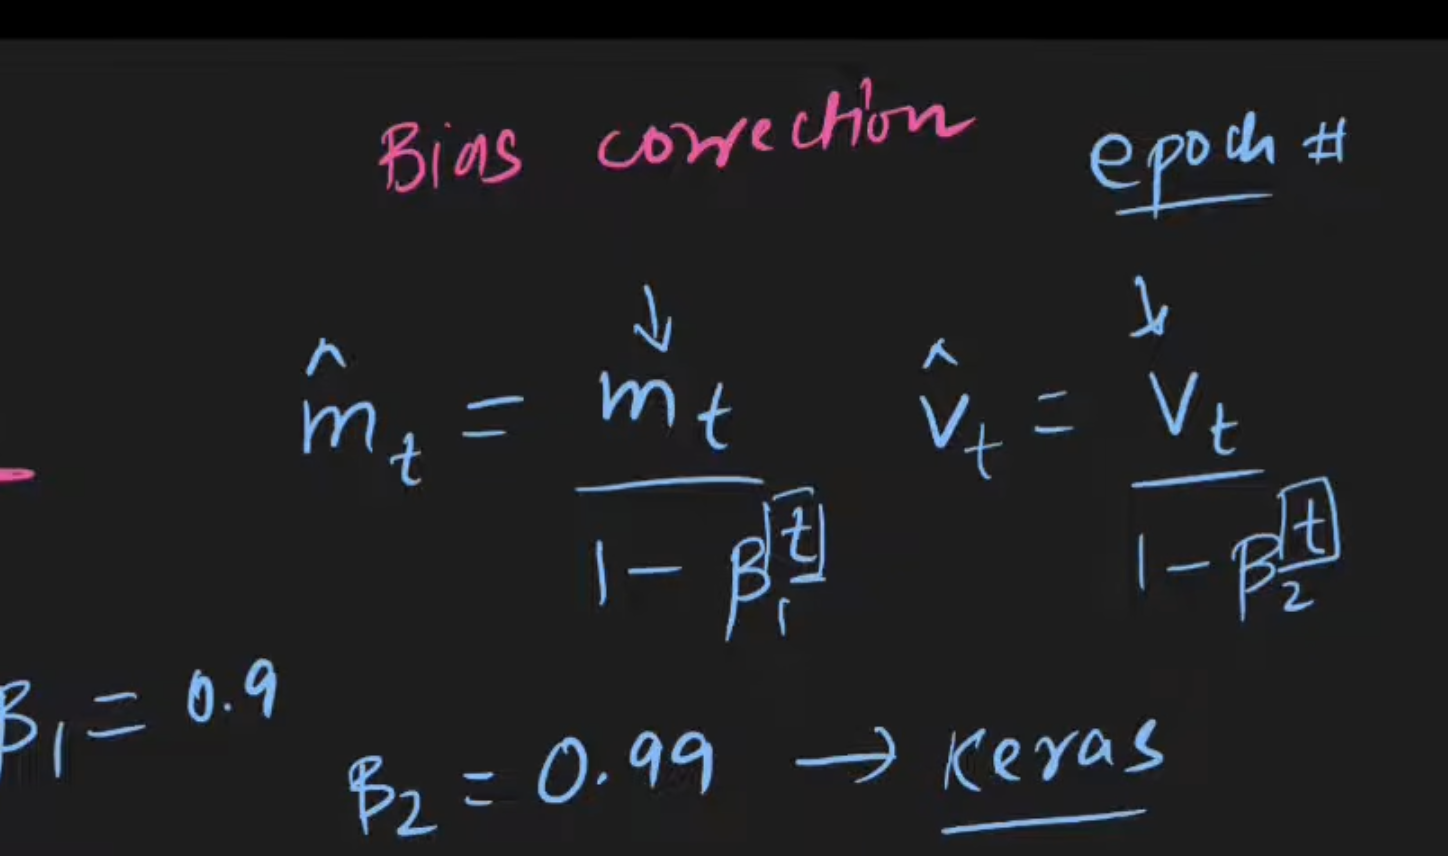
#### The Key Variables

| Symbol | Meaning | Initial value |
|--------|---------|---------------|
| `t` | Current time step (iteration number) | Starts at 0 |
| `mₜ` | First moment (mean of gradients) – momentum term | `m₀ = 0` |
| `vₜ` | Second moment (uncentered variance) – adaptive learning rate term | `v₀ = 0` |
| `β₁` | Decay rate for first moment | Usually `0.9` |
| `β₂` | Decay rate for second moment | Usually `0.999` |
| `ε` (epsilon) | Small number to prevent division by zero | e.g., `10⁻⁸` |
| `η` (eta) | Learning rate | You set this (e.g., `0.001`) |

#### Step‑by‑Step Mathematical Process

**Step 1: Compute the gradient** (same as any optimizer)
```
gₜ = ∇θ J(θₜ₋₁)
```
The gradient of the loss function with respect to the weights.

**Step 2: Update the first moment (momentum)**
```
mₜ = β₁ · mₜ₋₁ + (1 - β₁) · gₜ
```
- This is an **exponentially weighted moving average** of past gradients
- β₁ close to 1 (0.9) means we keep a lot of past momentum
- This is what gives Adam its "velocity"

**Step 3: Update the second moment (adaptive learning rate)**
```
vₜ = β₂ · vₜ₋₁ + (1 - β₂) · gₜ²
```
- This tracks the **magnitude** (squared) of gradients
- β₂ = 0.999 keeps a very long memory
- Larger gradients → larger `vₜ` → smaller effective learning rate

**Step 4: Bias correction** (explained in next topic)
```
m̂ₜ = mₜ / (1 - β₁ᵗ)
v̂ₜ = vₜ / (1 - β₂ᵗ)
```

**Step 5: Update the weights**
```
θₜ = θₜ₋₁ - η · (m̂ₜ / (√v̂ₜ + ε))
```

> **Intuition for the final formula:**
> - `m̂ₜ` = direction and speed (momentum)
> - `√v̂ₜ` = how much to scale down the step (adaptive rate)
> - You are **dividing the momentum by the adaptive factor**

#### The Two Core "Histories"

Adam reads **two histories** of past gradients:

| History | Stored in | Purpose |
|---------|-----------|---------|
| First moment (mean) | `mₜ` | Remember direction – keep moving the same way |
| Second moment (variance) | `vₜ` | Remember magnitude – slow down when gradients are large/noisy |

Both are applied **simultaneously** in a single formula.

#### Default Hyperparameters

| Parameter | Typical value | Meaning |
|-----------|---------------|---------|
| β₁ | 0.9 | More weight to past gradients for momentum |
| β₂ | 0.999 | Even more weight to past for adaptive rate |
| ε | 10⁻⁸ | Tiny – just prevents division by zero |
| η (learning rate) | 0.001 | You can change; Adam is somewhat robust to this |

These are **configurable** – you can change them if needed.

---

### 3. Key Points

- Adam maintains **two moving averages**:
  - `mₜ` (first moment) = momentum component
  - `vₜ` (second moment) = adaptive learning rate component
- The final weight update is: `θ = θ - η · m̂ₜ / (√v̂ₜ + ε)`
- β₁ controls momentum memory (default 0.9)
- β₂ controls adaptive rate memory (default 0.999)
- ε is a tiny constant to avoid division by zero

---

### 4. Syntax / Structure (Update Equations)

```
At iteration t (starting from t=1):

1. Compute gradient:     gₜ = ∇θ J(θₜ₋₁)

2. Update first moment:  mₜ = β₁·mₜ₋₁ + (1-β₁)·gₜ

3. Update second moment: vₜ = β₂·vₜ₋₁ + (1-β₂)·gₜ²

4. Bias correction:      m̂ₜ = mₜ / (1 - β₁ᵗ)
                         v̂ₜ = vₜ / (1 - β₂ᵗ)

5. Update weights:       θₜ = θₜ₋₁ - η · m̂ₜ / (√v̂ₜ + ε)
```

**Purpose of each line:**
- Line 1: Standard gradient computation
- Line 2: Keep running average of gradients (momentum)
- Line 3: Keep running average of squared gradients (adaptive scaling)
- Line 4: Fix initialization bias (important for early steps)
- Line 5: The actual weight update – momentum divided by adaptive scaling

---

### 5. Common Mistakes

| Mistake | Explanation | Fix |
|---------|-------------|-----|
| Confusing `m` and `v` | `m` is for momentum (mean), `v` is for variance (squared) | Remember: **m = mean, v = variance** |
| Forgetting bias correction | Without it, early updates are too small because `m₀=0, v₀=0` | Always apply bias correction, especially in early iterations |
| Using ε too large | Large ε makes the adaptive scaling meaningless | Keep ε tiny (1e-8) |
| Thinking β₁ and β₂ must sum to 1 | They are independent decay rates | No relationship; they control different things |

---

### 6. Interview / Exam Questions

**Q1:** Write the weight update formula for Adam.  
**A:** `θₜ = θₜ₋₁ - η · m̂ₜ / (√v̂ₜ + ε)`

**Q2:** What do `mₜ` and `vₜ` represent in Adam?  
**A:** `mₜ` is the first moment (mean of gradients – momentum). `vₜ` is the second moment (uncentered variance of squared gradients – adaptive learning rate).

**Q3:** What are the default values of β₁ and β₂?  
**A:** β₁ = 0.9, β₂ = 0.999

**Q4:** Why do we need both `mₜ` and `vₜ`? Why not just one?  
**A:** `mₜ` gives direction and speed (momentum). `vₜ` scales the step size per parameter (adaptive rate). Using both gives faster convergence and robustness to different gradient scales.

**Q5:** What does the small ε (epsilon) do?  
**A:** Prevents division by zero when `√v̂ₜ` is very small.

---

### 7. Revision Notes (Quick Recap)

| Component | Formula | Purpose |
|-----------|---------|---------|
| First moment (momentum) | `mₜ = β₁·mₜ₋₁ + (1-β₁)·gₜ` | Running average of gradients |
| Second moment (adaptive) | `vₜ = β₂·vₜ₋₁ + (1-β₂)·gₜ²` | Running average of squared gradients |
| Bias‑corrected m | `m̂ₜ = mₜ / (1-β₁ᵗ)` | Fixes initialization bias |
| Bias‑corrected v | `v̂ₜ = vₜ / (1-β₂ᵗ)` | Fixes initialization bias |
| Weight update | `θ -= η · m̂ₜ / (√v̂ₜ + ε)` | Final step |

**Default values:** β₁=0.9, β₂=0.999, ε=1e-8

---


## Topic 3: Bias Correction in Adam

### 1. Introduction

**What is bias correction?**  
Bias correction is a mathematical adjustment applied to `mₜ` and `vₜ` in the early steps of Adam. It fixes a problem caused by initializing both moment estimates to zero.

**Why is it important?**  
Without bias correction, Adam's early updates would be **too small** and biased toward zero. The optimizer would start very slowly, wasting training time. Bias correction "warms up" the estimates so they reflect true gradient statistics from the very first iteration.

**Real‑life use:**  
Every implementation of Adam (in PyTorch, TensorFlow, Keras, etc.) includes bias correction automatically. You don't need to code it manually, but understanding it helps you debug why early steps behave the way they do.

---

### 2. Detailed Explanation

#### The Problem: Initialization Bias

Both `mₜ` and `vₜ` are initialized to zero:

```
m₀ = 0
v₀ = 0
```

**Why is this a problem?**

Let's trace the first few updates:

**At t = 1 (first iteration):**

```
m₁ = β₁·m₀ + (1-β₁)·g₁
    = β₁·0 + (1-β₁)·g₁
    = (1-β₁)·g₁
```

Since β₁ = 0.9, `(1-β₁) = 0.1`. So:

```
m₁ = 0.1 · g₁
```

But **we want** `m₁` to be approximately `g₁` (the true gradient). Instead, it's only 10% of the true value. This is a **bias toward zero**.

Similarly for `v₁`:

```
v₁ = (1-β₂)·g₁² = 0.001 · g₁²   (since 1-0.999 = 0.001)
```

Both estimates are **too small** in early iterations.

#### The Analogy

Imagine you're averaging temperatures, but you start your record with a fake reading of 0°C on day 0.

- Day 1 actual temperature: 30°C
- Your running average: `0.9×0 + 0.1×30 = 3°C` (wrong!)
- You need to **correct** this artificially low estimate.

That's exactly what bias correction does.

#### The Solution: Bias Correction Formula

Divide the biased estimate by a factor that accounts for the initialization:

```
m̂ₜ = mₜ / (1 - β₁ᵗ)

v̂ₜ = vₜ / (1 - β₂ᵗ)
```

Where `β₁ᵗ` means β₁ raised to the power of t.

#### Why This Works (Step by Step)

**At t = 1:**

```
m̂₁ = m₁ / (1 - β₁¹) = (1-β₁)·g₁ / (1-β₁) = g₁
```

Perfect! The corrected estimate equals the true gradient.

**At t = 2:**

The correction factor is smaller `(1 - β₁²)`, and it exactly cancels the accumulated bias from the exponential moving average.

As `t` increases, `β₁ᵗ` approaches zero (since 0.9¹⁰⁰ is extremely tiny). So:

```
For large t:  1 - β₁ᵗ ≈ 1
Thus:  m̂ₜ ≈ mₜ
```

Bias correction **automatically fades away** after the first few iterations. It only matters at the beginning.

#### Visual Summary

| Time step (t) | β₁ᵗ (for β₁=0.9) | 1 - β₁ᵗ | Effect |
|---------------|------------------|---------|--------|
| 1 | 0.9 | 0.1 | Strong correction (multiply by 10) |
| 2 | 0.81 | 0.19 | Moderate correction (multiply by ~5.3) |
| 10 | 0.35 | 0.65 | Mild correction (multiply by ~1.5) |
| 50 | ~0.005 | 0.995 | Negligible correction (multiply by ~1.005) |

After about 50 steps, bias correction has virtually no effect.

---

### 3. Key Points

- Bias correction fixes the problem of `m₀ = 0` and `v₀ = 0`
- Without it, early updates are **too small** (biased toward zero)
- Formula: `m̂ₜ = mₜ / (1 - β₁ᵗ)` and `v̂ₜ = vₜ / (1 - β₂ᵗ)`
- Correction is **strong at first** and **fades away** as t increases
- After many iterations, `m̂ₜ ≈ mₜ` and `v̂ₜ ≈ vₜ`
- Most deep learning libraries handle this automatically

---

### 4. Complete Update With Bias Correction

Here's how bias correction fits into the full Adam algorithm:

```
At iteration t:

1. gₜ = ∇θ J(θₜ₋₁)

2. mₜ = β₁·mₜ₋₁ + (1-β₁)·gₜ

3. vₜ = β₂·vₜ₋₁ + (1-β₂)·gₜ²

4. m̂ₜ = mₜ / (1 - β₁ᵗ)      ← Bias correction

5. v̂ₜ = vₜ / (1 - β₂ᵗ)      ← Bias correction

6. θₜ = θₜ₋₁ - η · m̂ₜ / (√v̂ₜ + ε)
```

---

### 5. Common Mistakes

| Mistake | Explanation | Fix |
|---------|-------------|-----|
| Forgetting to apply bias correction | Early updates are too small, training starts slowly | Always include bias correction, especially for short training runs |
| Applying bias correction to `mₜ` but not `vₜ` | Both estimates are biased initially | Correct both `m` and `v` |
| Using bias correction for all iterations when implementing manually | Not wrong, but wasteful after many steps | It's fine to keep it – the factor approaches 1 anyway |
| Confusing `β₁ᵗ` with `β₁ × t` | The `t` is an **exponent**, not multiplication | Write it as `β₁ ** t` in code, not `β₁ * t` |

---

### 6. Interview / Exam Questions

**Q1:** Why does Adam need bias correction?  
**A:** Because `m₀` and `v₀` are initialized to zero. This causes the moving averages to be biased toward zero in early iterations, making updates too small. Bias correction fixes this.

**Q2:** Write the bias correction formulas.  
**A:** `m̂ₜ = mₜ / (1 - β₁ᵗ)` and `v̂ₜ = vₜ / (1 - β₂ᵗ)`

**Q3:** Does bias correction matter after 100 iterations? Why or why not?  
**A:** Very little. As t increases, `βᵗ` approaches 0, so `1 - βᵗ ≈ 1`, making `m̂ₜ ≈ mₜ`.

**Q4:** What happens if you remove bias correction from Adam?  
**A:** Early training steps will be too conservative (small updates). The optimizer may converge slower or get stuck in suboptimal regions.

**Q5:** Is bias correction unique to Adam?  
**A:** It's used in other optimizers that initialize moment estimates to zero (e.g., RMSprop with bias correction variants). Adam popularized it.

---

### 7. Revision Notes (Quick Recap)

**Problem:** `m₀ = 0`, `v₀ = 0` → early estimates are biased toward zero → updates are too small

**Solution:** Bias correction
```
m̂ₜ = mₜ / (1 - β₁ᵗ)
v̂ₜ = vₜ / (1 - β₂ᵗ)
```

**Effect over time:**

| Early iterations | Later iterations |
|-----------------|------------------|
| Strong correction | Correction ≈ 1 |
| Essential for good start | Negligible effect |

**Key insight:** You don't need to deeply understand the mathematical derivation. Just know that bias correction exists to **offset the zero initialization**, and libraries handle it for you.

---



## Topic 4: Adam Performance & Comparison with Other Optimizers

### 1. Introduction

**How does Adam actually perform?**  
Adam combines the best behaviors of previous optimizers. It descends **smoothly and quickly** toward the minimum, without the extreme oscillations of pure momentum or the premature stopping of AdaGrad.

**Why compare optimizers?**  
No single optimizer is perfect for every problem. Understanding how Adam compares to others helps you:
- Choose the right optimizer for your project
- Diagnose why your model isn't training well
- Decide when to switch away from Adam

---

### 2. Detailed Explanation

#### Visualizing the Differences

The transcript describes a scenario with **sparse data** (e.g., one column is sparse/crossed). Different optimizers behave very differently:

| Optimizer | Behavior on Sparse Data | Problem |
|-----------|------------------------|---------|
| **Basic Momentum** | Descends quickly in one direction first, then slowly moves to the other | Wastes time zigzagging |
| **Adam** | Descends diagonally (from the center), optimizing both directions simultaneously | Efficient and balanced |

> **Analogy:**  
> Imagine you're at the top of a ridge and need to reach the lowest point in a valley below.  
> - **Momentum** = You run straight down the steepest slope first, then have to climb sideways.  
> - **Adam** = You take a diagonal path that balances both directions from the start.

#### Adam's Observed Behavior

From the transcript's animation description:

- **Momentum alone:** Descends in large circles, oscillates, slowly settles
- **NAG (Nesterov):** Smaller oscillations than momentum, but still not perfect on sparse data
- **AdaGrad:** Descends directly on sparse data, but **misses the minimum** because learning rate decays too much
- **RMSprop:** Fixes the decay problem and reaches the bottom
- **Adam:** Shows **both behaviors** – momentum AND learning rate decay – converging from the center in an optimized, rotating pattern

#### Summary of Optimizer Evolution

```
Batch GD → too slow
    ↓
Momentum → faster, but oscillates
    ↓
NAG → dampens oscillations, but slow on sparse data
    ↓
AdaGrad → good on sparse data, but learning rate decays to zero
    ↓
RMSprop → fixes decay, reaches bottom
    ↓
ADAM → combines momentum + RMSprop → best of both worlds
```

#### Performance on Non‑Convex Problems

| Problem Type | Adam Performance |
|--------------|------------------|
| **Convex** (simple bowl shape) | Works well, but advantage less obvious |
| **Non‑convex** (real neural networks with many local minima) | **Performs very well** – this is where Adam shines |

Real deep learning problems are **non‑convex**. Adam's ability to handle complex loss landscapes is why it's so popular.

---

### 3. Which Optimizer Should You Use?

#### General Recommendation (from the transcript)

> *"In most cases, if you're working in deep learning, Adam is a good starting point. You can try Adam directly."*

**Tiered approach:**

| Order | Try this | When |
|-------|----------|------|
| 1st | **Adam** | Default starting point for most problems |
| 2nd | **RMSprop** | If Adam gives poor results |
| 3rd | **Momentum** | Sometimes works better on certain problems |

#### Important Caveat

> *"There's no clear answer. In the last 3-4 years, Adam has generally been giving better results over different kinds of problems."*

**But:** You should still experiment. Hyperparameter tuning on your specific data may reveal that another optimizer works better.

#### Decision Flowchart

```
Start new project
       ↓
Try Adam with default settings
       ↓
Results good? ──Yes──→ Use Adam
       │
       No
       ↓
Try RMSprop
       ↓
Results good? ──Yes──→ Use RMSprop
       │
       No
       ↓
Try Momentum / NAG
       ↓
Tune hyperparameters for all
       ↓
Pick best performing one
```

---

### 4. Key Points

- Adam descends **diagonally/from the center** – efficiently balancing multiple gradient directions
- Shows **both** momentum behavior AND learning rate decay behavior
- Works **especially well on non‑convex problems** (real neural networks)
- **Adam is the most used optimizer** in deep learning today
- Start with Adam by default; switch only if results are poor
- Other options: RMSprop, Momentum, NAG, AdaGrad, AdaDelta
- No universal "best" – depends on your specific data and architecture

---

### 5. Common Mistakes

| Mistake | Why it's wrong | How to avoid |
|---------|----------------|--------------|
| Always using Adam without trying others | You might be leaving performance on the table | Do a quick A/B test with RMSprop and Momentum |
| Switching away from Adam too quickly | Adam's default settings often work; tuning might fix issues | Tune Adam's learning rate and β₁/β₂ first |
| Using AdaGrad for deep networks | Learning rate decays to zero – training stops | Use Adam or RMSprop instead |
| Assuming convex performance equals non‑convex performance | An optimizer good on simple problems may fail on complex ones | Test on your actual architecture |

---

### 6. Interview / Exam Questions

**Q1:** On what type of problem does Adam perform especially well?  
**A:** Non‑convex optimization problems, which are typical in real neural networks.

**Q2:** What optimizer should you try first on a new deep learning project?  
**A:** Adam is generally a good starting point.

**Q3:** If Adam gives poor results, what should you try next?  
**A:** RMSprop, and then Momentum.

**Q4:** Why is Adam described as showing "both behaviors" of momentum and learning rate decay?  
**A:** Because it maintains both a first moment (momentum) and a second moment (adaptive learning rate), combining the advantages of both.

**Q5:** Is Adam always the best optimizer?  
**A:** No. While it works well on many problems, sometimes Momentum or RMSprop gives better results depending on the data and architecture.

---

### 7. Revision Notes (Quick Recap)

**Optimizer lineage (problems → solutions):**

| Problem | Solution |
|---------|----------|
| Too slow | Momentum |
| Oscillations | NAG |
| Sparse data issues | AdaGrad |
| Learning rate decay to zero | RMSprop |
| Combine best of all | **ADAM** |

**Adam's unique behavior:**
- Descends from center (diagonally)
- Balances multiple gradient directions
- Smooth rotation toward minimum

**Recommendation:**
```
Default: ADAM
    ↓ if poor
Try: RMSprop
    ↓ if poor
Try: Momentum / NAG
```

**Bottom line:** Adam is the modern default. Start there, but don't be afraid to experiment.

---


## Topic 5: Final Summary & Practical Takeaways

### 1. Introduction

**What have we covered?**  
Adam (Adaptive Moment Estimation) is the most famous and widely used optimizer in deep learning. It combines momentum (for speed) with adaptive learning rates (for robustness), and includes bias correction to fix initialization problems.

**Why this matters for you as a beginner:**  
You don't need to implement Adam from scratch. But understanding what happens "under the hood" helps you:
- Talk intelligently about optimizers in interviews
- Debug training issues when models don't converge
- Make informed decisions about which optimizer to use

---

### 2. Complete Summary of Adam

#### One‑Sentence Summary

> Adam is an optimizer that keeps a running average of both past gradients (momentum) and past squared gradients (adaptive learning rate), then uses bias‑corrected versions of these to update weights efficiently.

#### The Five Core Concepts

| Concept | What it does | In simple terms |
|---------|--------------|-----------------|
| **First moment (m)** | Tracks direction and speed | "Keep moving the same way" |
| **Second moment (v)** | Tracks gradient magnitude | "Slow down when gradients are noisy" |
| **Bias correction** | Fixes zero initialization | "Warm up the estimates" |
| **Learning rate (η)** | Step size – but Adam adapts it | "You set it, Adam adjusts it" |
| **β₁, β₂** | Decay rates for the moments | "How much memory to keep" |

#### The Complete Algorithm (Mental Model)

```
For each training step:

1. Calculate the gradient (slope of the loss)

2. Update the momentum memory (m):
   New m = 0.9 × old m + 0.1 × current gradient

3. Update the adaptive memory (v):
   New v = 0.999 × old v + 0.001 × (gradient²)

4. Correct the bias (divide by something < 1, mostly early on)

5. Update weights:
   weights = weights - learning_rate × (corrected_m / √(corrected_v))
```

---

### 3. Quick Reference Table

| Aspect | Value |
|--------|-------|
| **Full name** | Adaptive Moment Estimation |
| **Combines** | Momentum + RMSprop |
| **Default β₁** | 0.9 |
| **Default β₂** | 0.999 |
| **Default ε** | 10⁻⁸ |
| **Typical learning rate** | 0.001 |
| **When to use** | Default first choice for most deep learning |
| **When to avoid** | When RMSprop or Momentum clearly outperform on your data |

---

### 4. Common Mistakes Recap

| Mistake | Correction |
|---------|------------|
| Thinking Adam needs no hyperparameter tuning | Defaults work well, but tuning can improve results |
| Using Adam on very small datasets | Bias correction helps, but simple optimizers may suffice |
| Not knowing why Adam works | Understand momentum + adaptive rates conceptually |
| Never trying other optimizers | Adam is a start, not always the end |

---

### 5. Interview / Exam Questions (Consolidated)

**Q1:** What does Adam stand for?  
**A:** Adaptive Moment Estimation.

**Q2:** What two concepts does Adam combine?  
**A:** Momentum (first moment) and adaptive learning rates from RMSprop (second moment).

**Q3:** Write the final weight update formula.  
**A:** `θₜ = θₜ₋₁ - η · m̂ₜ / (√v̂ₜ + ε)`

**Q4:** Why does Adam need bias correction?  
**A:** Because `m₀=0` and `v₀=0` cause early estimates to be biased toward zero, making updates too small.

**Q5:** What are the default β₁ and β₂ values?  
**A:** β₁ = 0.9, β₂ = 0.999.

**Q6:** Is Adam always the best optimizer?  
**A:** No. It's a great starting point, but RMSprop or Momentum may work better on some problems.

**Q7:** On what type of problem does Adam excel?  
**A:** Non‑convex optimization problems typical in real neural networks.

**Q8:** What should you do if Adam gives poor results?  
**A:** Try RMSprop, then Momentum, and tune hyperparameters.

---

### 6. Revision Notes (Quick Recap)

**Adam = Adaptive Moment Estimation**

**The essence:**
```
m = momentum (direction)
v = adaptive scaling (step size control)
update = -η × (m / √v)
```

**Default values to remember:**
- β₁ = 0.9 (momentum decay)
- β₂ = 0.999 (adaptive rate decay)
- η = 0.001 (learning rate)

**Two‑line summary for interviews:**
> "Adam keeps two moving averages: one of past gradients (momentum) and one of past squared gradients (adaptive learning rate). It corrects for initialization bias and updates weights by dividing the momentum by the square root of the adaptive term."

**Practical advice:**
1. Start with Adam as your default optimizer
2. If results are poor, try RMSprop
3. If still poor, try Momentum
4. Always tune hyperparameters for your specific data

---

### 7. Prerequisites Checklist

To fully understand Adam, you should be familiar with:

| Earlier optimizer | What you should know |
|------------------|----------------------|
| Batch / Mini‑batch GD | Basic gradient descent |
| Momentum | Velocity, damping oscillations |
| NAG (Nesterov) | Looking ahead to dampen oscillations |
| AdaGrad | Adaptive learning rates, decay problem |
| RMSprop | Fixing AdaGrad's decay |

> *"If you want to understand Adam properly, you need to have an idea about all these techniques."*

---

### 8. Final Takeaway

> *"Adam is currently the most powerful optimization technique. Most of the time, if you're working with a neural network, you're optimizing it with Adam."*

**As a beginner:**
- Don't implement Adam from scratch (use PyTorch/TensorFlow)
- Do understand the concepts: momentum + adaptive rates + bias correction
- Do start with Adam on your projects
- Do experiment with other optimizers when needed

---

**This completes all topics on Adam Optimizer from the transcript.**

